In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ========================================
# 🛠️ STEP 1: Install & Setup Environment
# ========================================
!pip install kagglehub ultralytics

import kagglehub
import os
import torch
from ultralytics import YOLO

In [3]:
# Detect available GPUs
num_gpus = torch.cuda.device_count()
print(f"🚀 Found {num_gpus} GPU(s) available for training.")

🚀 Found 2 GPU(s) available for training.


In [4]:
# Create device list for YOLO (e.g., [0, 1] for dual T4 GPUs)
device_config = list(range(num_gpus)) if num_gpus > 0 else 'cpu'

In [5]:
# ========================================
# 📦 STEP 2: Download Dataset
# ========================================
base_path = kagglehub.dataset_download("aliabdelmenam/rdd-2022")
dataset_path = os.path.join(base_path, "RDD_SPLIT")

train_images = os.path.join(dataset_path, "train/images")
val_images = os.path.join(dataset_path, "val/images")
test_images = os.path.join(dataset_path, "test/images")

assert os.path.exists(train_images), "Dataset path error. Ensure RDD_SPLIT exists."
print("✅ Dataset loaded dynamically!")

✅ Dataset loaded dynamically!


In [6]:
# ========================================
# 📝 STEP 3: Create dataset.yaml
# ========================================
# We output to /kaggle/working/ so files persist and don't get wiped easily
yaml_path = "/kaggle/working/rdd2022.yaml"
yaml_content = f"""
train: {train_images}
val: {val_images}
test: {test_images}

nc: 4
names: ['Longitudinal_Crack', 'Transverse_Crack', 'Alligator_Crack', 'Pothole']
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"✅ YAML configuration saved to {yaml_path}")

✅ YAML configuration saved to /kaggle/working/rdd2022.yaml


In [7]:
# ========================================
# 🤖 STEP 4: Train with Multi-GPU Support
# ========================================
model = YOLO("yolov8n.pt")

# Calculate optimal batch size (YOLO divides this across the available GPUs)
# If using 2 GPUs, a batch of 32 means 16 images per GPU.
optimal_batch = 16 * num_gpus if num_gpus > 0 else 16

results = model.train(
    data=yaml_path,
    epochs=20,           
    imgsz=640,
    batch=optimal_batch,  # Scales with your GPU count
    device=device_config, # Triggers multi-GPU training
    workers=4,            # Kaggle gives you enough CPU cores to load data fast
    project="/kaggle/working/RoadDamageDetection", # Output strictly to Kaggle working dir
    name="yolov8_multi_gpu",
    hsv_s=0.5,
    hsv_v=0.4
)

print("✅ Training complete. Weights saved in /kaggle/working/RoadDamageDetection/yolov8_multi_gpu/weights/best.pt")

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rdd2022.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_multi_gpu, nbs

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.9 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numb

🔍 Running inference on 2 sample images...

0: 480x640 1 Alligator_Crack, 19.7ms
1: 480x640 1 Alligator_Crack, 19.7ms
Speed: 1.7ms preprocess, 19.7ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/detect/predict-3


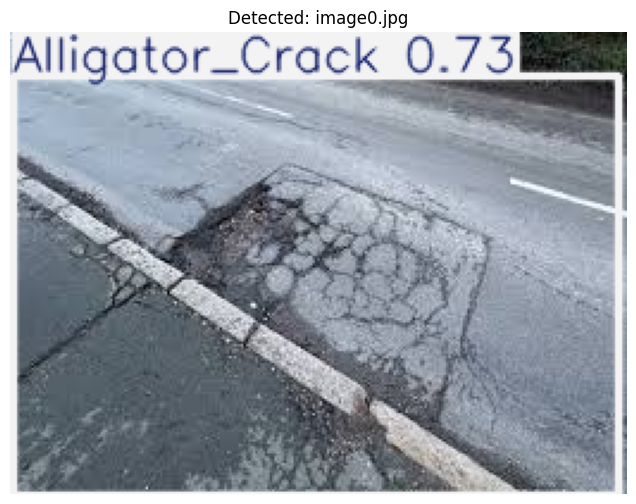

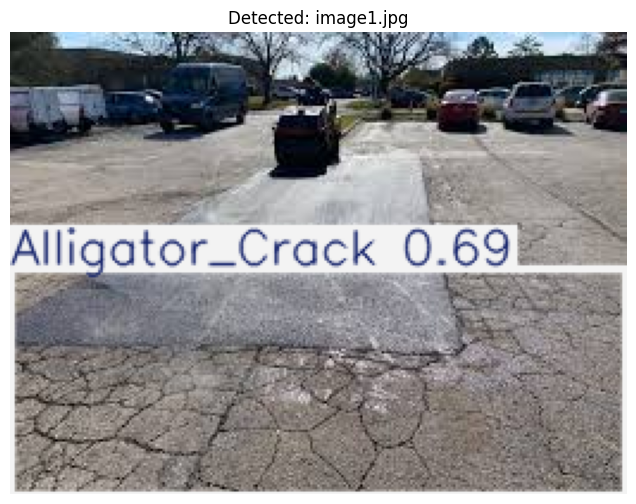

In [7]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your trained model weights
model_path = "/kaggle/input/models/harmanpreetsingh0105/best-detector/other/default/1/best.pt"
model = YOLO(model_path)

# 2. Find sample images from the test split
# Update this path if your test image directory differs
test_images_path = "/kaggle/input/models/harmanpreetsingh0105/potholes/other/default/1"
image_files = glob.glob(os.path.join(test_images_path, "*.jpeg"))[:5] # Take 5 samples

if not image_files:
    print("❌ No images found. Please verify your test_images_path.")
else:
    print(f"🔍 Running inference on {len(image_files)} sample images...")
    
    # 3. Run prediction
    # save=True automatically saves visual results to runs/detect/predict/
    results = model.predict(source=image_files, conf=0.25, save=True)
    
    # 4. Display the results inside the notebook
    for result in results:
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        img_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"Detected: {os.path.basename(result.path)}")
        plt.show()